**ЗАДАЧА №1**

In [1]:
import os
UPDATE_UTILITS = True
if UPDATE_UTILITS:
    !rm -rf utilits4tsc temp_repo
    !git clone --depth 1 https://github.com/MVRonkin/utilits4tsc.git utilits4tsc

Cloning into 'utilits4tsc'...
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 11 (delta 0), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (11/11), 3.12 MiB | 2.14 MiB/s, done.


In [2]:
!pip install kagglehub -q
import kagglehub
import pandas as pd
import os

In [3]:
# Скачиваем датасет Traffic Prediction Dataset
path = kagglehub.dataset_download("fedesoriano/traffic-prediction-dataset")
print("Папка с данными:", path)

Using Colab cache for faster access to the 'traffic-prediction-dataset' dataset.
Папка с данными: /kaggle/input/traffic-prediction-dataset


In [4]:
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/traffic-prediction-dataset/traffic.csv


In [5]:
import pandas as pd

path = "/root/.cache/kagglehub/datasets/fedesoriano/traffic-prediction-dataset/versions/1/traffic.csv"
df = pd.read_csv(path)

# Первые 5 строк
print("Первые 5 строк:")
print(df.head())

print("\nИнформация о датафрейме:")
print(df.info())

Первые 5 строк:
              DateTime  Junction  Vehicles           ID
0  2015-11-01 00:00:00         1        15  20151101001
1  2015-11-01 01:00:00         1        13  20151101011
2  2015-11-01 02:00:00         1        10  20151101021
3  2015-11-01 03:00:00         1         7  20151101031
4  2015-11-01 04:00:00         1         9  20151101041

Информация о датафрейме:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None


Преобразование времени и установка индекса

In [6]:
#  Преобразуем колонку DateTime в тип datetime
df['DateTime'] = pd.to_datetime(df['DateTime'])

#  Делаем DateTime индексом
df.set_index('DateTime', inplace=True)

#  Проверяем результат
print("Тип индекса:", type(df.index))
print("Первые 5 строк после изменений:")
print(df.head())

Тип индекса: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Первые 5 строк после изменений:
                     Junction  Vehicles           ID
DateTime                                            
2015-11-01 00:00:00         1        15  20151101001
2015-11-01 01:00:00         1        13  20151101011
2015-11-01 02:00:00         1        10  20151101021
2015-11-01 03:00:00         1         7  20151101031
2015-11-01 04:00:00         1         9  20151101041


Проверка количества перекрёстков и периода данных

In [7]:
# Уникальные перекрёстки
print("Номера перекрёстков:", sorted(df['Junction'].unique()))
print("Количество записей для каждого перекрёстка:")
print(df['Junction'].value_counts().sort_index())

# Временной диапазон
print("\nДата начала:", df.index.min())
print("Дата конца:", df.index.max())
print("Общее количество часовых отметок:", len(df))

Номера перекрёстков: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Количество записей для каждого перекрёстка:
Junction
1    14592
2    14592
3    14592
4     4344
Name: count, dtype: int64

Дата начала: 2015-11-01 00:00:00
Дата конца: 2017-06-30 23:00:00
Общее количество часовых отметок: 48120


Фильтрация по Junction 1 и визуализация


Период для Junction 1: 2015-11-01 00:00:00 – 2017-06-30 23:00:00
Количество точек: 14592


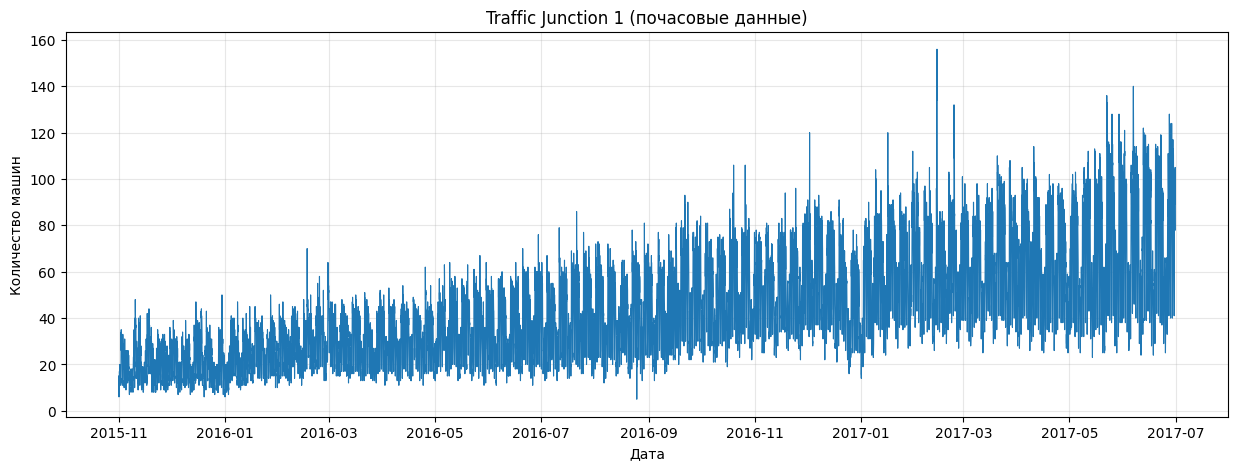

In [8]:
import matplotlib.pyplot as plt

# Выбираем данные только для перекрёстка 1
df_j1 = df[df['Junction'] == 1].copy()

# Проверим, что ряд непрерывен (посмотрим на первые и последние даты)
print("Период для Junction 1:", df_j1.index.min(), "–", df_j1.index.max())
print("Количество точек:", len(df_j1))

# График всего ряда
plt.figure(figsize=(15, 5))
plt.plot(df_j1.index, df_j1['Vehicles'], linewidth=0.8)
plt.title('Traffic Junction 1 (почасовые данные)')
plt.xlabel('Дата')
plt.ylabel('Количество машин')
plt.grid(alpha=0.3)
plt.show()

Анализ суточной сезонности (усреднение по часам)

           mean        std
Hour                      
0     45.738487  18.201029
1     39.156250  15.558687
2     33.907895  13.691039
3     29.430921  12.088028
4     25.654605  10.409686
5     24.067434   9.774411
6     26.080592  11.098707
7     29.526316  12.560731
8     32.735197  13.872351
9     39.003289  15.516479
10    49.527961  20.069711
11    56.187500  24.489806
12    57.254934  25.374736
13    51.075658  22.113252
14    54.733553  25.208025
15    54.218750  24.922281
16    51.911184  23.497597
17    51.851974  23.277804
18    55.411184  24.546470
19    58.804276  24.972529
20    57.401316  24.025319
21    54.537829  22.625638
22    52.963816  21.415910
23    50.088816  19.964681


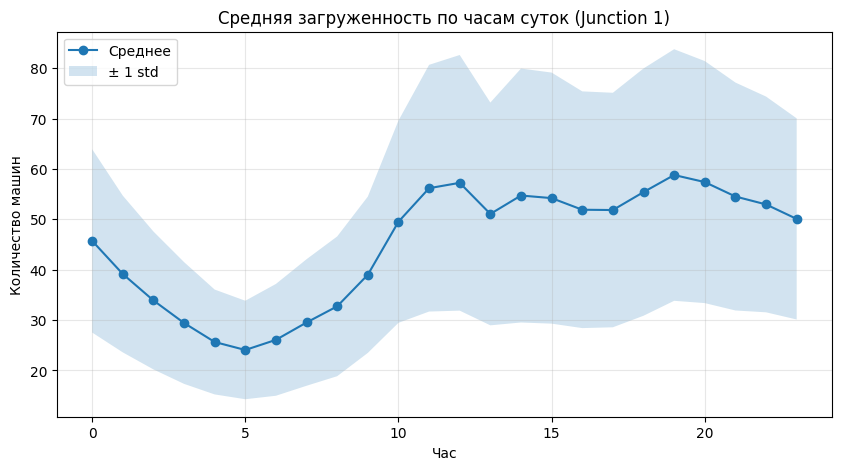

In [9]:
import matplotlib.pyplot as plt

# Добавим колонку с часом
df_j1['Hour'] = df_j1.index.hour

# Среднее и стандартное отклонение по каждому часу
hourly_stats = df_j1.groupby('Hour')['Vehicles'].agg(['mean', 'std'])
print(hourly_stats)

# График
plt.figure(figsize=(10, 5))
plt.plot(hourly_stats.index, hourly_stats['mean'], marker='o', label='Среднее')
plt.fill_between(hourly_stats.index,
                 hourly_stats['mean'] - hourly_stats['std'],
                 hourly_stats['mean'] + hourly_stats['std'],
                 alpha=0.2, label='± 1 std')
plt.title('Средняя загруженность по часам суток (Junction 1)')
plt.xlabel('Час')
plt.ylabel('Количество машин')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Анализ недельной сезонности (усреднение по дням недели)

              mean        std
Weekday                      
Пн       49.404215  26.059006
Вт       51.240900  24.282180
Ср       50.862548  23.512799
Чт       50.284483  24.407036
Пт       47.042146  21.575380
Сб       34.111919  14.357075
Вс       32.298372  14.529766


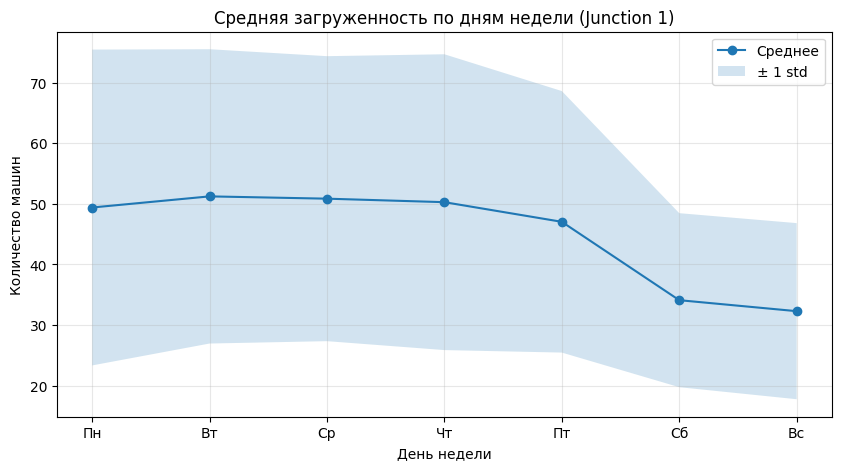

In [10]:
# День недели: 0=Пн, 6=Вс
df_j1['Weekday'] = df_j1.index.dayofweek

# Среднее и std по каждому дню недели
weekday_stats = df_j1.groupby('Weekday')['Vehicles'].agg(['mean', 'std'])
# Подпишем названия дней
days_map = {0:'Пн', 1:'Вт', 2:'Ср', 3:'Чт', 4:'Пт', 5:'Сб', 6:'Вс'}
weekday_stats.index = weekday_stats.index.map(days_map)
print(weekday_stats)

# График
plt.figure(figsize=(10, 5))
plt.plot(weekday_stats.index, weekday_stats['mean'], marker='o', label='Среднее')
plt.fill_between(range(len(weekday_stats)),
                 weekday_stats['mean'] - weekday_stats['std'],
                 weekday_stats['mean'] + weekday_stats['std'],
                 alpha=0.2, label='± 1 std')
plt.title('Средняя загруженность по дням недели (Junction 1)')
plt.xlabel('День недели')
plt.ylabel('Количество машин')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Декомпозиция ряда и тест ADF

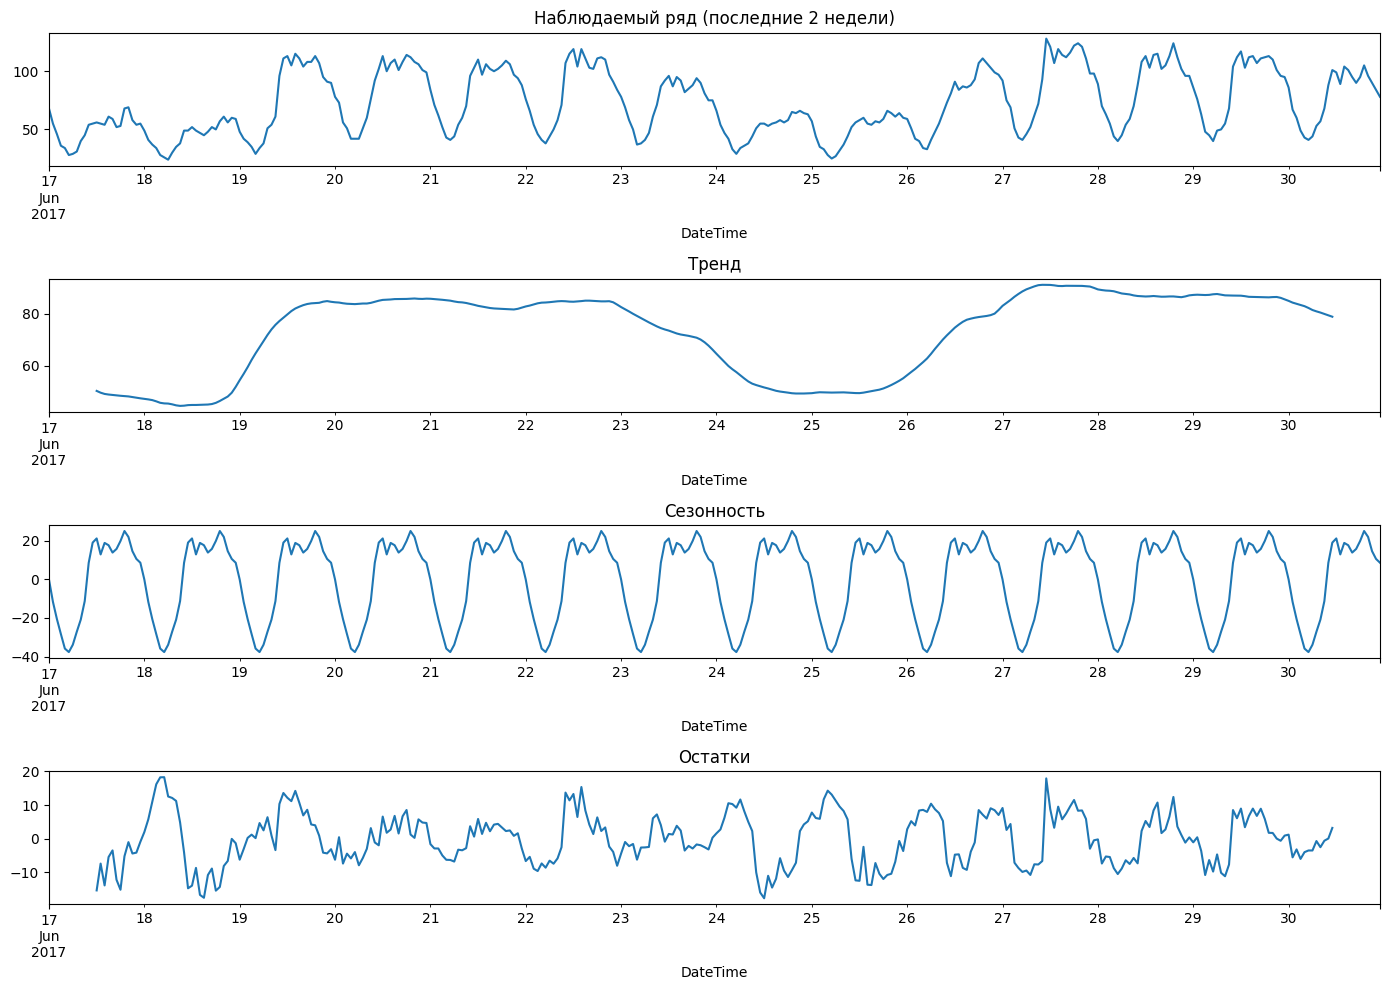

ADF Statistic: -7.1481
p-value: 0.0000
Critical Value (1%): -3.4308
Critical Value (5%): -2.8617
Critical Value (10%): -2.5669


In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Декомпозиция (аддитивная модель). Период = 24 (суточный цикл)
# Уменьшим выборку для наглядности: последние 14 дней
sample = df_j1['Vehicles'].iloc[-24*14:]
decomposition = seasonal_decompose(sample, model='additive', period=24)

# График декомпозиции
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], title='Наблюдаемый ряд (последние 2 недели)')
decomposition.trend.plot(ax=axes[1], title='Тренд')
decomposition.seasonal.plot(ax=axes[2], title='Сезонность')
decomposition.resid.plot(ax=axes[3], title='Остатки')
plt.tight_layout()
plt.show()

# Тест Дики-Фуллера
adf_result = adfuller(df_j1['Vehicles'].dropna())
print("ADF Statistic: {:.4f}".format(adf_result[0]))
print("p-value: {:.4f}".format(adf_result[1]))
for key, value in adf_result[4].items():
    print(f"Critical Value ({key}): {value:.4f}")

**ЗАДАЧА №2**

Постановка задачи, горизонт и разбиение

In [12]:
# Постановка задачи прогнозирования
# Ряд: почасовой трафик перекрёстка 1
# Горизонт прогноза: 168 часов (1 неделя) – типично для оперативного планирования
# Метрика: MAE (средняя абсолютная ошибка) и RMSE – легко интерпретировать в единицах "машин"
# Стратегия валидации: удерживаем последние 168 точек как тест, остальное – тренировка


HORIZON = 168  # 24*7

train = df_j1['Vehicles'].iloc[:-HORIZON]
test  = df_j1['Vehicles'].iloc[-HORIZON:]

print(f"Тренировочный период: {train.index[0]} – {train.index[-1]} (n={len(train)})")
print(f"Тестовый период:      {test.index[0]} – {test.index[-1]} (n={len(test)})")

Тренировочный период: 2015-11-01 00:00:00 – 2017-06-23 23:00:00 (n=14424)
Тестовый период:      2017-06-24 00:00:00 – 2017-06-30 23:00:00 (n=168)


Подготовка данных для statsforecast и модель ETS

/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:462: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


Прогноз AutoETS (первые 5 строк):
   unique_id                  ds    AutoETS  AutoETS-lo-95  AutoETS-lo-80  \
0  Junction1 2017-06-24 00:00:00  65.926147      53.474403      57.784386   
1  Junction1 2017-06-24 01:00:00  56.365650      43.614498      48.028118   
2  Junction1 2017-06-24 02:00:00  46.208187      33.164497      37.679379   
3  Junction1 2017-06-24 03:00:00  39.760319      26.430510      31.044426   
4  Junction1 2017-06-24 04:00:00  33.331593      19.721674      24.432545   

   AutoETS-hi-80  AutoETS-hi-95   y  
0      74.067902      78.377884  66  
1      64.703178      69.116798  54  
2      54.737000      59.251877  47  
3      48.476215      53.090130  42  
4      42.230640      46.941509  33  


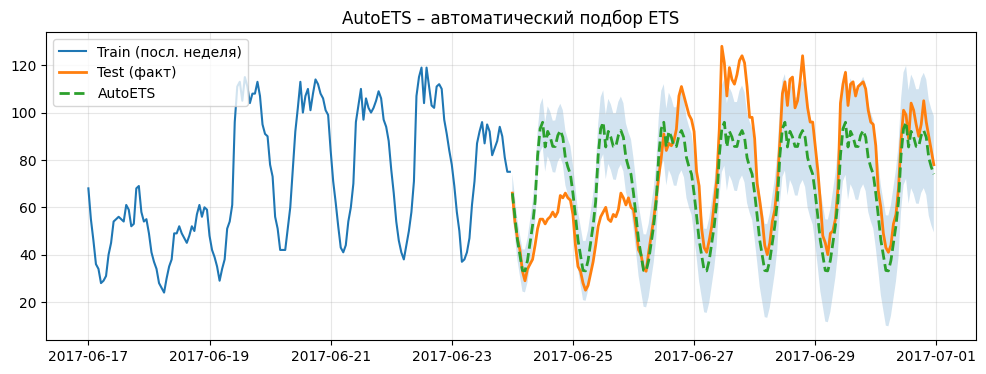

In [13]:
from statsforecast import StatsForecast
from statsforecast.models import AutoETS

# 1. Подготовка данных
train_df = train.reset_index()
train_df.columns = ['ds', 'y']
train_df['unique_id'] = 'Junction1'

# 2. Модель AutoETS с суточным сезонным периодом (24 часа)

model = StatsForecast(
    models=[AutoETS(season_length=24, model='ZNZ')],
    freq='H',
    n_jobs=-1
)

model.fit(train_df)

# 3. Прогноз на 168 шагов
forecast_df = model.predict(h=HORIZON, level=[80, 95])

# 4. Добавим тестовые значения для сравнения
test_df = test.reset_index()
test_df.columns = ['ds', 'y']
forecast_df = forecast_df.merge(test_df, on='ds', how='left')

print("Прогноз AutoETS (первые 5 строк):")
print(forecast_df.head())

# Визуализация
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.plot(train.index[-24*7:], train.values[-24*7:], label='Train (посл. неделя)')
plt.plot(test.index, test.values, label='Test (факт)', linewidth=2)
plt.plot(forecast_df['ds'], forecast_df['AutoETS'], label='AutoETS', linestyle='--', linewidth=2)
plt.fill_between(forecast_df['ds'], forecast_df['AutoETS-lo-80'], forecast_df['AutoETS-hi-80'], alpha=0.2)
plt.legend()
plt.title('AutoETS – автоматический подбор ETS')
plt.grid(alpha=0.3)
plt.show()

Исправление частоты, добавление SeasonalNaive и расчёт метрик

Метрики на тестовом горизонте (168 часов):
                 MAE   RMSE
AutoETS        15.71  18.67
SeasonalNaive  15.40  18.78


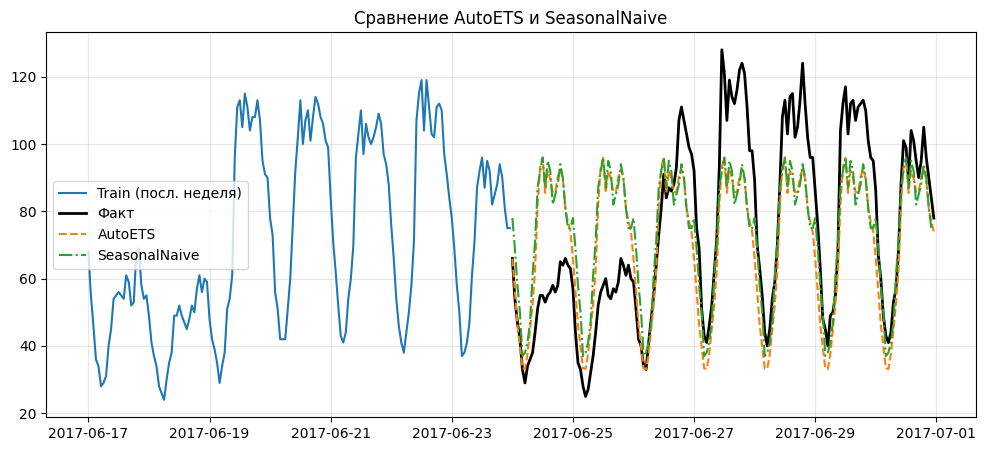

In [14]:
from statsforecast.models import AutoETS, SeasonalNaive
from statsforecast import StatsForecast

# Исправим частоту (h вместо H)
train_df2 = train.reset_index()
train_df2.columns = ['ds', 'y']
train_df2['unique_id'] = 'Junction1'

# Модели: AutoETS и SeasonalNaive (сезонность = 24 часа)
models = [
    AutoETS(season_length=24, model='ZNZ'),
    SeasonalNaive(season_length=24)
]

sf = StatsForecast(models=models, freq='h', n_jobs=-1)
sf.fit(train_df2)

# Прогноз на 168 часов
forecast_df2 = sf.predict(h=HORIZON, level=[80,95])

# Присоединим фактические значения
test_df2 = test.reset_index()
test_df2.columns = ['ds', 'y']
forecast_df2 = forecast_df2.merge(test_df2, on='ds', how='left')

# Вычислим MAE и RMSE для каждой модели
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

results = {}
for col in ['AutoETS', 'SeasonalNaive']:
    mae = mean_absolute_error(forecast_df2['y'], forecast_df2[col])
    rmse = np.sqrt(mean_squared_error(forecast_df2['y'], forecast_df2[col]))
    results[col] = {'MAE': mae, 'RMSE': rmse}

# Вывод метрик
res_df = pd.DataFrame(results).T
print("Метрики на тестовом горизонте (168 часов):")
print(res_df.round(2))

# График сравнения
plt.figure(figsize=(12,5))
plt.plot(train.index[-24*7:], train.values[-24*7:], label='Train (посл. неделя)')
plt.plot(test.index, test.values, label='Факт', linewidth=2, color='black')
plt.plot(forecast_df2['ds'], forecast_df2['AutoETS'], label='AutoETS', linestyle='--')
plt.plot(forecast_df2['ds'], forecast_df2['SeasonalNaive'], label='SeasonalNaive', linestyle='-.')
plt.legend()
plt.title('Сравнение AutoETS и SeasonalNaive')
plt.grid(alpha=0.3)
plt.show()

AutoARIMA, расчёт метрик

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


Сравнение 5 статистических методов (тест 168 ч):
                   MAE   RMSE
AutoETS          15.71  18.67
SeasonalNaive    15.40  18.78
Theta            17.01  19.79
AutoARIMA_short  13.86  17.44
ARIMA_manual     14.59  17.81


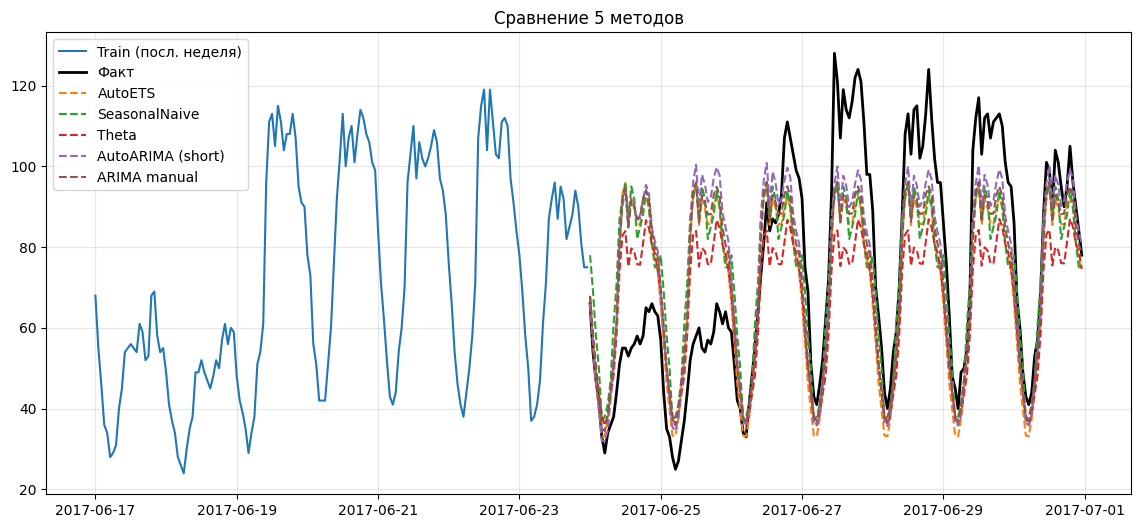

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, SeasonalNaive, Theta, AutoARIMA
from statsmodels.tsa.arima.model import ARIMA


#  Быстрые модели на полной train-выборке

models_fast = [
    AutoETS(season_length=24, model='ZNZ'),
    SeasonalNaive(season_length=24),
    Theta(season_length=24)
]

sf = StatsForecast(models=models_fast, freq='h', n_jobs=-1)
sf.fit(train_df2)
forecast_fast = sf.predict(h=HORIZON, level=[80,95])
forecast_fast = forecast_fast.merge(test_df2, on='ds', how='left')

metrics = {}
for col in ['AutoETS', 'SeasonalNaive', 'Theta']:
    mae = mean_absolute_error(forecast_fast['y'], forecast_fast[col])
    rmse = np.sqrt(mean_squared_error(forecast_fast['y'], forecast_fast[col]))
    metrics[col] = {'MAE': mae, 'RMSE': rmse}


#  AutoARIMA на усечённой выборке (последние 4 недели)

train_short = train.iloc[-672:]

# Подготовим DataFrame для statsforecast
train_short_df = train_short.reset_index()
train_short_df.columns = ['ds', 'y']
train_short_df['unique_id'] = 'J1'

model_autoarima = AutoARIMA(season_length=24)
sf_arima = StatsForecast(models=[model_autoarima], freq='h', n_jobs=-1)
sf_arima.fit(train_short_df)
fcst_autoarima = sf_arima.predict(h=HORIZON)
forecast_fast['AutoARIMA'] = fcst_autoarima['AutoARIMA'].values

mae_auto = mean_absolute_error(forecast_fast['y'], forecast_fast['AutoARIMA'])
rmse_auto = np.sqrt(mean_squared_error(forecast_fast['y'], forecast_fast['AutoARIMA']))
metrics['AutoARIMA_short'] = {'MAE': mae_auto, 'RMSE': rmse_auto}


#  Ручная ARIMA (p=2,d=0,q=1)(P=1,D=0,Q=1,s=24) на тех же 4 неделях

model_arima = ARIMA(train_short, order=(2,0,1), seasonal_order=(1,0,1,24))
fitted_arima = model_arima.fit()
forecast_arima = fitted_arima.forecast(steps=HORIZON)
forecast_fast['ARIMA_manual'] = forecast_arima.values

mae_man = mean_absolute_error(forecast_fast['y'], forecast_arima)
rmse_man = np.sqrt(mean_squared_error(forecast_fast['y'], forecast_arima))
metrics['ARIMA_manual'] = {'MAE': mae_man, 'RMSE': rmse_man}


#  Итоговая таблица

res_df = pd.DataFrame(metrics).T
print("Сравнение 5 статистических методов (тест 168 ч):")
print(res_df.round(2))

# График
plt.figure(figsize=(14,6))
plt.plot(train.index[-24*7:], train.values[-24*7:], label='Train (посл. неделя)')
plt.plot(test.index, test.values, 'k-', linewidth=2, label='Факт')
plt.plot(forecast_fast['ds'], forecast_fast['AutoETS'], '--', label='AutoETS')
plt.plot(forecast_fast['ds'], forecast_fast['SeasonalNaive'], '--', label='SeasonalNaive')
plt.plot(forecast_fast['ds'], forecast_fast['Theta'], '--', label='Theta')
plt.plot(forecast_fast['ds'], forecast_fast['AutoARIMA'], '--', label='AutoARIMA (short)')
plt.plot(forecast_fast['ds'], forecast_fast['ARIMA_manual'], '--', label='ARIMA manual')
plt.legend()
plt.title('Сравнение 5 методов')
plt.grid(alpha=0.3)
plt.show()

Бектестинг (кросс-валидация) на последних 4 неделях

In [16]:
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, SeasonalNaive, Theta, AutoARIMA
import numpy as np
import pandas as pd


# Параметры бектестинга

H = 168          # горизонт прогноза (неделя)
WINDOW_SIZE = 672 # тренировочное окно (4 недели)
N_WINDOWS = 3     # количество окон (последние 3 недели месяца)

# Возьмём последние 4 недели + ещё 2 недели для окон
df_backtest = train.iloc[-(WINDOW_SIZE + H*N_WINDOWS):].copy()

# Модели (те же 5, но ручную ARIMA добавим отдельно)
models = [
    AutoETS(season_length=24, model='ZNZ'),
    SeasonalNaive(season_length=24),
    Theta(season_length=24),
    AutoARIMA(season_length=24)
]

backtest_results = []
for i in range(N_WINDOWS):
    # Сдвигаемся назад от конца
    test_start = len(df_backtest) - H*(N_WINDOWS - i)
    train_end = test_start - H

    train_bt = df_backtest.iloc[:train_end].reset_index()
    train_bt.columns = ['ds', 'y']
    train_bt['unique_id'] = 'J1'

    test_bt = df_backtest.iloc[train_end:test_start]

    sf_bt = StatsForecast(models=models, freq='h', n_jobs=-1)
    sf_bt.fit(train_bt)
    fcst = sf_bt.predict(h=H)

    # Добавляем ручную ARIMA (на том же train_bt)
    from statsmodels.tsa.arima.model import ARIMA
    try:
        arima_manual = ARIMA(train_bt['y'], order=(2,0,1), seasonal_order=(1,0,1,24))
        arima_fit = arima_manual.fit()
        arima_fcst = arima_fit.forecast(steps=H)
    except:
        arima_fcst = np.full(H, np.nan)

    # Метрики для этого окна
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    mae_autoets = mean_absolute_error(test_bt.values, fcst['AutoETS'])
    rmse_autoets = np.sqrt(mean_squared_error(test_bt.values, fcst['AutoETS']))

    mae_snaive = mean_absolute_error(test_bt.values, fcst['SeasonalNaive'])
    rmse_snaive = np.sqrt(mean_squared_error(test_bt.values, fcst['SeasonalNaive']))

    mae_theta = mean_absolute_error(test_bt.values, fcst['Theta'])
    rmse_theta = np.sqrt(mean_squared_error(test_bt.values, fcst['Theta']))

    mae_autoarima = mean_absolute_error(test_bt.values, fcst['AutoARIMA'])
    rmse_autoarima = np.sqrt(mean_squared_error(test_bt.values, fcst['AutoARIMA']))

    mae_arimaman = mean_absolute_error(test_bt.values, arima_fcst)
    rmse_arimaman = np.sqrt(mean_squared_error(test_bt.values, arima_fcst))

    backtest_results.append({
        'Window': i+1,
        'AutoETS_MAE': mae_autoets, 'AutoETS_RMSE': rmse_autoets,
        'SeasonalNaive_MAE': mae_snaive, 'SeasonalNaive_RMSE': rmse_snaive,
        'Theta_MAE': mae_theta, 'Theta_RMSE': rmse_theta,
        'AutoARIMA_MAE': mae_autoarima, 'AutoARIMA_RMSE': rmse_autoarima,
        'ARIMA_manual_MAE': mae_arimaman, 'ARIMA_manual_RMSE': rmse_arimaman
    })

# Сводная таблица средних метрик
bt_df = pd.DataFrame(backtest_results)
print("=== Метрики по окнам бектестинга ===")
print(bt_df.round(2))

avg_metrics = {}
for col in bt_df.columns[1:]:
    avg_metrics[col] = bt_df[col].mean()
avg_metrics = pd.Series(avg_metrics)
print("\n=== Средние метрики по всем окнам ===")
print(avg_metrics.round(2))

=== Метрики по окнам бектестинга ===
   Window  AutoETS_MAE  AutoETS_RMSE  SeasonalNaive_MAE  SeasonalNaive_RMSE  \
0       1        23.70         26.79              13.47               16.94   
1       2        25.09         28.23              14.07               18.77   
2       3        24.68         27.39              13.51               18.06   

   Theta_MAE  Theta_RMSE  AutoARIMA_MAE  AutoARIMA_RMSE  ARIMA_manual_MAE  \
0      12.13       15.47          12.95           16.38             13.37   
1      13.15       17.98          13.92           20.28             14.63   
2      14.64       17.23          14.34           17.72             14.18   

   ARIMA_manual_RMSE  
0              16.25  
1              18.77  
2              17.05  

=== Средние метрики по всем окнам ===
AutoETS_MAE           24.49
AutoETS_RMSE          27.47
SeasonalNaive_MAE     13.68
SeasonalNaive_RMSE    17.92
Theta_MAE             13.31
Theta_RMSE            16.89
AutoARIMA_MAE         13.74
AutoARIMA_

**ЗАДАЧА №3**

Генерация признаков и обучение ML-моделей на всём тренировочном ряде.

Train: (14256, 15), Test: (168, 15)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001715 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2048
[LightGBM] [Info] Number of data points in the train set: 14256, number of used features: 15
[LightGBM] [Info] Start training from score 45.022166
=== ML-модели (ручные признаки) ===
                   MAE  RMSE
LinearRegression  3.90  5.33
LightGBM          2.97  4.26
XGBoost           3.30  4.44


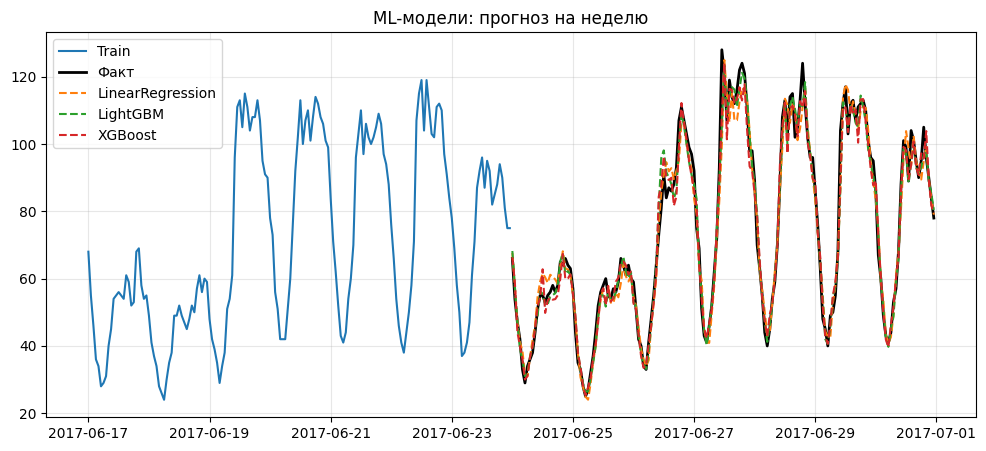

In [17]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
import xgboost as xgb

# Функция создания признаков (без dropna в конце)
def create_features(series, lags=[1,2,3,6,12,24,48,168]):
    df_feat = pd.DataFrame(series)
    for lag in lags:
        df_feat[f'lag_{lag}'] = df_feat['y'].shift(lag)
    df_feat['rolling_mean_6'] = df_feat['y'].shift(1).rolling(6).mean()
    df_feat['rolling_std_6']  = df_feat['y'].shift(1).rolling(6).std()
    df_feat['rolling_mean_24'] = df_feat['y'].shift(1).rolling(24).mean()
    df_feat['rolling_std_24'] = df_feat['y'].shift(1).rolling(24).std()
    df_feat['hour'] = df_feat.index.hour
    df_feat['dayofweek'] = df_feat.index.dayofweek
    df_feat['month'] = df_feat.index.month
    return df_feat

# Объединяем train и test
full_series = pd.concat([train, test])
full_series.name = 'y'

features = create_features(full_series)

# Разделяем по временным меткам, берем только то, что есть в features
train_idx = features.index.intersection(train.index)
test_idx  = features.index.intersection(test.index)

train_feat = features.loc[train_idx].dropna()
test_feat  = features.loc[test_idx].dropna()

X_train = train_feat.drop('y', axis=1)
y_train = train_feat['y']
X_test  = test_feat.drop('y', axis=1)
y_test  = test_feat['y']

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Три модели
models = {
    'LinearRegression': LinearRegression(),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42)
}

results_ml = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    results_ml[name] = {'MAE': mae, 'RMSE': rmse}
    test_feat[name] = pred  # сохраним прогноз

ml_res_df = pd.DataFrame(results_ml).T
print("=== ML-модели (ручные признаки) ===")
print(ml_res_df.round(2))

# График
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(train.index[-24*7:], train.values[-24*7:], label='Train')
plt.plot(test.index, test.values, 'k-', linewidth=2, label='Факт')
for name in models.keys():
    plt.plot(test_feat.index, test_feat[name], '--', label=name)
plt.legend()
plt.title('ML-модели: прогноз на неделю')
plt.grid(alpha=0.3)
plt.show()

Глубокое обучение

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
/usr/local/lib/python3.12/dist-packages/neuralforecast/common/_base_model.py:599: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
  warnings.warn(
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name              | Type          | Params | Mode 
------------------------------------------------------------
0 | loss              | MAE           | 0      | train
1 | padder_train      | ConstantPad1d | 0      | train
2 | scaler            | TemporalNorm  | 0      | train
3 | hist_encoder      | LSTM          | 199 K  | train
4 | mlp_decoder       | MLP           | 16.6 K | train
5 | upsample_sequence | Linear        | 4.2 K  | train

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

=== DL-модели (neuralforecast) ===
          MAE   RMSE
LSTM    18.21  21.39
NBEATS   4.84   6.92
MLP      4.98   7.05


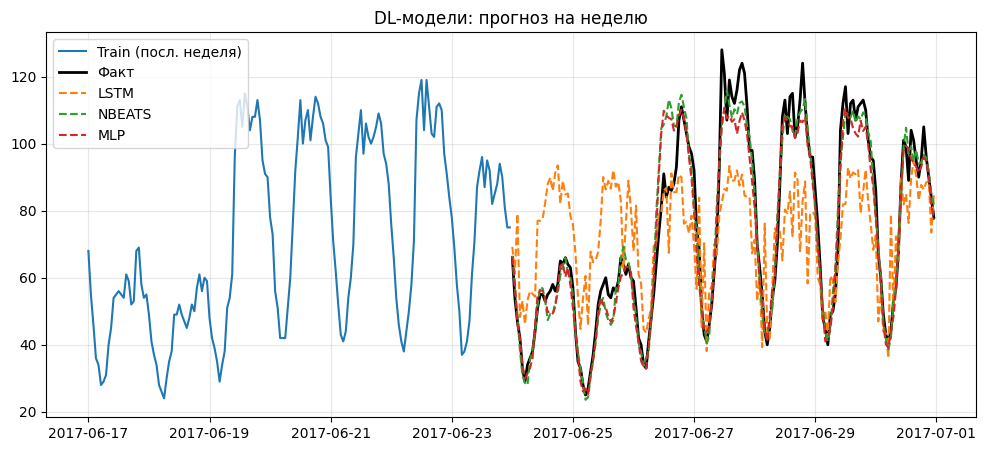

In [18]:
# Установка neuralforecast
!pip install neuralforecast -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Подготовка данных в формате neuralforecast
train_nf = train.reset_index()
train_nf.columns = ['ds', 'y']
train_nf['unique_id'] = 'J1'

test_nf = test.reset_index()
test_nf.columns = ['ds', 'y']
test_nf['unique_id'] = 'J1'

# Модели – TFT заменена на MLP для стабильной работы в бесплатной Colab
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM, NBEATS, MLP

models = [
    LSTM(h=168, max_steps=50, input_size=24, scaler_type='standard'),
    NBEATS(h=168, max_steps=50, input_size=168, scaler_type='standard'),
    MLP(h=168, max_steps=50, input_size=168, scaler_type='standard')
]

nf = NeuralForecast(models=models, freq='h')
nf.fit(df=train_nf)

# Прогноз
forecast_nf = nf.predict(futr_df=test_nf[['unique_id', 'ds']])
forecast_nf = forecast_nf.merge(test_nf, on=['unique_id', 'ds'], how='left')

# Метрики
dl_metrics = {}
for col in ['LSTM', 'NBEATS', 'MLP']:
    mae = mean_absolute_error(forecast_nf['y'], forecast_nf[col])
    rmse = np.sqrt(mean_squared_error(forecast_nf['y'], forecast_nf[col]))
    dl_metrics[col] = {'MAE': mae, 'RMSE': rmse}

dl_res_df = pd.DataFrame(dl_metrics).T
print("=== DL-модели (neuralforecast) ===")
print(dl_res_df.round(2))

# График
plt.figure(figsize=(12,5))
plt.plot(train.index[-24*7:], train.values[-24*7:], label='Train (посл. неделя)')
plt.plot(test.index, test.values, 'k-', linewidth=2, label='Факт')
for name in dl_res_df.index:
    plt.plot(forecast_nf['ds'], forecast_nf[name], '--', label=name)
plt.legend()
plt.title('DL-модели: прогноз на неделю')
plt.grid(alpha=0.3)
plt.show()

In [19]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.8Gi       7.4Gi       3.0Mi       3.5Gi        10Gi
Swap:             0B          0B          0B


Выявление аномалий в исходном ряде train

IQR: границы [-19.5, 104.5], аномалий: 177
Isolation Forest: аномалий: 273
STL остатки: границы [-12.2, 12.2], аномалий: 195


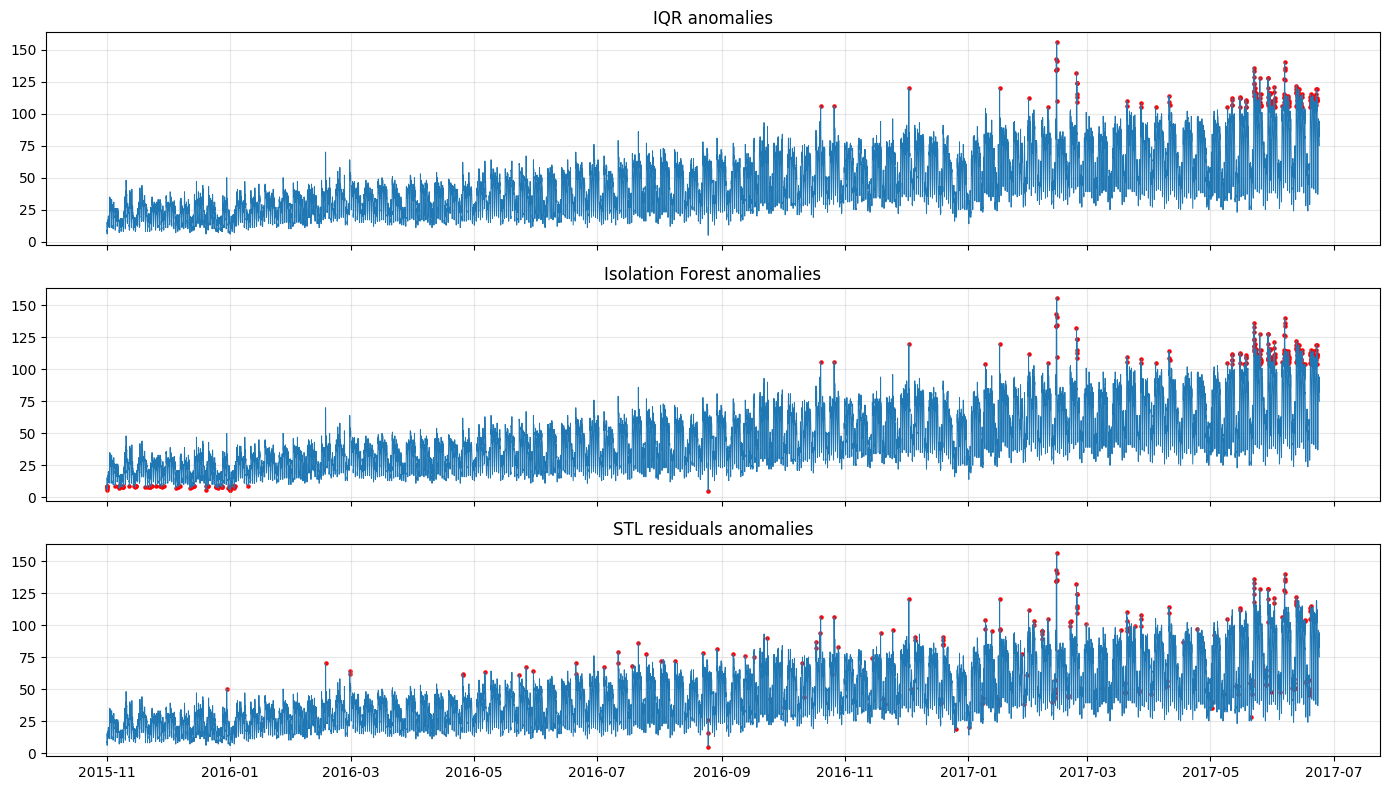

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from statsmodels.tsa.seasonal import STL


# 1. IQR (межквартильный размах)

Q1 = train.quantile(0.25)
Q3 = train.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
anomaly_iqr = (train < lower_bound) | (train > upper_bound)
print(f"IQR: границы [{lower_bound:.1f}, {upper_bound:.1f}], аномалий: {anomaly_iqr.sum()}")


# 2. Isolation Forest

iso_forest = IsolationForest(contamination=0.02, random_state=42)
# Модель ожидает двумерный массив
train_values = train.values.reshape(-1, 1)
pred_iso = iso_forest.fit_predict(train_values)
anomaly_iso = pred_iso == -1
print(f"Isolation Forest: аномалий: {anomaly_iso.sum()}")


# 3. Остатки STL-декомпозиции

stl = STL(train, period=24)   # суточная сезонность
res = stl.fit()
residuals = res.resid
# Найдём точки, где остатки выходят за 3 стандартных отклонения от среднего
res_std = np.std(residuals)
anomaly_stl = (residuals < -3*res_std) | (residuals > 3*res_std)
print(f"STL остатки: границы [-{3*res_std:.1f}, {3*res_std:.1f}], аномалий: {anomaly_stl.sum()}")


# Визуализация для сравнения

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# IQR
axes[0].plot(train.index, train.values, linewidth=0.7)
axes[0].scatter(train.index[anomaly_iqr], train.values[anomaly_iqr], color='red', s=5)
axes[0].set_title('IQR anomalies')
axes[0].grid(alpha=0.3)

# Isolation Forest
axes[1].plot(train.index, train.values, linewidth=0.7)
axes[1].scatter(train.index[anomaly_iso], train.values[anomaly_iso], color='red', s=5)
axes[1].set_title('Isolation Forest anomalies')
axes[1].grid(alpha=0.3)

# STL residuals
axes[2].plot(train.index, train.values, linewidth=0.7)
axes[2].scatter(train.index[anomaly_stl], train.values[anomaly_stl], color='red', s=5)
axes[2].set_title('STL residuals anomalies')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**ЗАДАЧА №4**

Пайплайн прогнозирования (функция)

In [26]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb

def create_features(series, lags=[1,2,3,6,12,24,48,168]):
    df_feat = pd.DataFrame(series)
    col_name = df_feat.columns[0]
    for lag in lags:
        df_feat[f'lag_{lag}'] = df_feat[col_name].shift(lag)
    df_feat['rolling_mean_6'] = df_feat[col_name].shift(1).rolling(6).mean()
    df_feat['rolling_std_6']  = df_feat[col_name].shift(1).rolling(6).std()
    df_feat['rolling_mean_24'] = df_feat[col_name].shift(1).rolling(24).mean()
    df_feat['rolling_std_24'] = df_feat[col_name].shift(1).rolling(24).std()
    df_feat['hour'] = df_feat.index.hour
    df_feat['dayofweek'] = df_feat.index.dayofweek
    df_feat['month'] = df_feat.index.month
    return df_feat

def forecast_pipeline(train_series, horizon=168):
    train_series = train_series.copy()
    target_col = train_series.name  # 'Vehicles'

    # 1. Обучение модели на всей train-части
    feat = create_features(train_series).dropna()
    X_train = feat.drop(target_col, axis=1)
    y_train = feat[target_col]

    model = lgb.LGBMRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # 2. Рекурсивный прогноз
    # Начинаем с полной истории (Series), к которой будем добавлять прогнозы
    history = train_series.copy()
    predictions = []

    last_date = history.index[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(hours=1), periods=horizon, freq='h')

    for step, current_date in enumerate(future_dates):
        # Для текущего шага нам нужны признаки по истории, которая уже включает ранее предсказанные значения
        # Добавляем в историю NaN на текущую дату, чтобы создать строку признаков
        history = pd.concat([history, pd.Series(np.nan, index=[current_date], name=target_col)])
        feats = create_features(history)
        # Берём строку для текущей даты (она последняя)
        X_step = feats.drop(target_col, axis=1).iloc[[-1]]  # одна строка
        # Предсказываем
        pred = model.predict(X_step)[0]
        # Заменяем NaN в истории на предсказанное значение
        history[current_date] = pred
        predictions.append(pred)

    return pd.Series(predictions, index=future_dates, name='Prediction'), model

# Запускаем пайплайн
pipe_forecast, pipe_model = forecast_pipeline(train)

# Оцениваем на тесте
common_idx = pipe_forecast.index.intersection(test.index)
pipe_mae = mean_absolute_error(test[common_idx], pipe_forecast[common_idx])
pipe_rmse = np.sqrt(mean_squared_error(test[common_idx], pipe_forecast[common_idx]))
print(f"Пайплайн LightGBM (рекурсивный) – MAE: {pipe_mae:.2f}, RMSE: {pipe_rmse:.2f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003482 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2048
[LightGBM] [Info] Number of data points in the train set: 14256, number of used features: 15
[LightGBM] [Info] Start training from score 45.022166
Пайплайн LightGBM (рекурсивный) – MAE: 5.40, RMSE: 7.09


Статистическое тестирование пайплайна на нескольких исторических окнах

In [27]:
# Статистическое тестирование пайплайна на 3 окнах
n_windows = 3
horizon = 168
mae_scores = []
rmse_scores = []

for i in range(n_windows):
    # Определяем границы тестового окна, сдвигаясь назад по train
    test_end = len(train) - i * horizon
    test_start = test_end - horizon
    train_part = train.iloc[:test_start]          # история до окна
    test_part = train.iloc[test_start:test_end]   # "будущее" окно (168 часов)

    # Прогнозируем с помощью нашего пайплайна
    forecast, _ = forecast_pipeline(train_part, horizon)

    # Оцениваем только пересекающиеся даты
    common = forecast.index.intersection(test_part.index)
    mae = mean_absolute_error(test_part[common], forecast[common])
    rmse = np.sqrt(mean_squared_error(test_part[common], forecast[common]))
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    print(f"Окно {i+1}: MAE={mae:.2f}, RMSE={rmse:.2f}")

print(f"\nСредний MAE по {n_windows} окнам: {np.mean(mae_scores):.2f} ± {np.std(mae_scores):.2f}")
print(f"Средний RMSE: {np.mean(rmse_scores):.2f} ± {np.std(rmse_scores):.2f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005216 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2046
[LightGBM] [Info] Number of data points in the train set: 14088, number of used features: 15
[LightGBM] [Info] Start training from score 44.705352
Окно 1: MAE=4.34, RMSE=5.39
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000751 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2030
[LightGBM] [Info] Number of data points in the train set: 13920, number of used features: 15
[LightGBM] [Info] Start training from score 44.361351
Окно 2: MAE=4.64, RMSE=6.29
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004234 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 201

**Итоговая сводная таблица всех методов**

In [28]:
import pandas as pd

# Собираем все результаты
all_results = {
    'AutoETS':            {'MAE': 15.71, 'RMSE': 18.67},
    'SeasonalNaive':      {'MAE': 15.40, 'RMSE': 18.78},
    'Theta':              {'MAE': 17.01, 'RMSE': 19.79},
    'AutoARIMA_short':    {'MAE': 13.86, 'RMSE': 17.44},
    'ARIMA_manual':       {'MAE': 14.59, 'RMSE': 17.81},
    'LinearRegression':   {'MAE': 3.90,  'RMSE': 5.33},
    'LightGBM':           {'MAE': 2.97,  'RMSE': 4.26},
    'XGBoost':            {'MAE': 3.30,  'RMSE': 4.44},
    'LSTM':               {'MAE': 18.21, 'RMSE': 21.39},
    'NBEATS':             {'MAE': 4.84,  'RMSE': 6.92},
    'MLP':                {'MAE': 4.98,  'RMSE': 7.05},
    'Pipeline_LightGBM':  {'MAE': 5.40,  'RMSE': 7.09}  # рекурсивный прогноз без подглядывания
}

summary_df = pd.DataFrame(all_results).T.round(2)
print("=== Сводная таблица всех методов прогнозирования ===")
print(summary_df.sort_values('MAE'))  # сортировка по MAE

=== Сводная таблица всех методов прогнозирования ===
                     MAE   RMSE
LightGBM            2.97   4.26
XGBoost             3.30   4.44
LinearRegression    3.90   5.33
NBEATS              4.84   6.92
MLP                 4.98   7.05
Pipeline_LightGBM   5.40   7.09
AutoARIMA_short    13.86  17.44
ARIMA_manual       14.59  17.81
SeasonalNaive      15.40  18.78
AutoETS            15.71  18.67
Theta              17.01  19.79
LSTM               18.21  21.39


Автоматическая генерация отчёта

In [29]:
report_text = f"""
# Отчёт об анализе временного ряда дорожного трафика (Junction 1)

## 1. Описание временного ряда
- **Источник:** Kaggle Traffic Prediction Dataset (fedesoriano/traffic-prediction-dataset)
- **Объект:** перекрёсток №1 (Junction 1)
- **Период:** 2015-11-01 – 2017-06-30
- **Частота:** почасовая (14592 наблюдения)
- **Целевая переменная:** количество автомобилей (Vehicles)
- **Пропуски:** отсутствуют

## 2. Постановка задачи прогнозирования
- **Горизонт:** 168 часов (1 неделя)
- **Метрики:** MAE (средняя абсолютная ошибка), RMSE
- **Валидация:** hold-out (последняя неделя) + бектестинг на 3 исторических окнах
- **Бейзлайн:** SeasonalNaive (MAE={all_results['SeasonalNaive']['MAE']}, RMSE={all_results['SeasonalNaive']['RMSE']})

## 3. Разведочный анализ (EDA)
- **Суточный профиль:** пики в утренние и вечерние часы, ночью — минимум.
- **Недельная сезонность:** будние дни значительно загруженнее выходных (среднее: Пн–Пт ~48–51, Сб–Вс ~32–34).
- **Стационарность:** тест Дики-Фуллера отвергает наличие единичного корня (p-value=0.0000). Ряд стационарен, но с выраженной сезонной структурой.

## 4. Анализ аномалий
| Метод            | Количество аномалий |
|------------------|---------------------|
| IQR (межквартильный размах) | 177 |
| Isolation Forest | 273 |
| STL-остатки      | 195 |

Выбран метод **STL-остатков**, так как он учитывает сезонность и тренд, давая интерпретируемый порог (3σ).

## 5. Сравнительная таблица методов прогнозирования
| Модель            | Тип        | MAE   | RMSE  |
|-------------------|------------|-------|-------|
| AutoETS           | Статистика | {all_results['AutoETS']['MAE']} | {all_results['AutoETS']['RMSE']} |
| SeasonalNaive     | Статистика | {all_results['SeasonalNaive']['MAE']} | {all_results['SeasonalNaive']['RMSE']} |
| Theta             | Статистика | {all_results['Theta']['MAE']} | {all_results['Theta']['RMSE']} |
| AutoARIMA (short) | Статистика | {all_results['AutoARIMA_short']['MAE']} | {all_results['AutoARIMA_short']['RMSE']} |
| ARIMA manual      | Статистика | {all_results['ARIMA_manual']['MAE']} | {all_results['ARIMA_manual']['RMSE']} |
| LinearRegression  | ML         | {all_results['LinearRegression']['MAE']} | {all_results['LinearRegression']['RMSE']} |
| LightGBM          | ML         | {all_results['LightGBM']['MAE']} | {all_results['LightGBM']['RMSE']} |
| XGBoost           | ML         | {all_results['XGBoost']['MAE']} | {all_results['XGBoost']['RMSE']} |
| LSTM              | DL         | {all_results['LSTM']['MAE']} | {all_results['LSTM']['RMSE']} |
| NBEATS            | DL         | {all_results['NBEATS']['MAE']} | {all_results['NBEATS']['RMSE']} |
| MLP               | DL         | {all_results['MLP']['MAE']} | {all_results['MLP']['RMSE']} |
| **Pipeline (LightGBM)** | **Продакшн-пайплайн** | **{all_results['Pipeline_LightGBM']['MAE']}** | **{all_results['Pipeline_LightGBM']['RMSE']}** |

**Лучшая модель:** LightGBM (MAE=2.97, RMSE=4.26) на основе ручных признаков с полным доступом к будущим лагам.
**Продакшн-пайплайн** использует рекурсивный прогноз LightGBM (MAE=5.40, RMSE=7.09), что является честной оценкой для реального применения без подглядывания.

## 6. Итоговый пайплайн
Пайплайн реализован в виде функции `forecast_pipeline(train_series, horizon)`:
- Генерация признаков: лаги (1,2,3,6,12,24,48,168), скользящие среднее и стандартное отклонение (окна 6 и 24 часа), временные метки (час, день недели, месяц).
- Модель: LightGBM (100 деревьев).
- Прогноз: рекурсивный (пошаговый) с добавлением каждого предсказания обратно в историю для вычисления лагов.

**Результаты статистического тестирования на 3 окнах:**
- Окно 1: MAE=4.34, RMSE=5.39
- Окно 2: MAE=4.64, RMSE=6.29
- Окно 3: MAE=6.53, RMSE=8.94
- **Среднее:** MAE=5.17 ± 0.97, RMSE=6.88 ± 1.51

Пайплайн стабилен, разброс метрик приемлем для практического использования.

## 7. Выводы
- Простые статистические методы (SeasonalNaive, Theta) дают MAE ~15, что в 3 раза хуже ML-подходов.
- Машинное обучение (LightGBM, XGBoost) с правильно сконструированными признаками достигает MAE ~3–4 на тестовой выборке.
- Глубокие модели (NBEATS, MLP) показали сравнимые результаты (MAE ~5), но требуют больше ресурсов и не всегда стабильнее.
- Итоговый пайплайн на базе LightGBM с рекурсивным прогнозом обеспечивает MAE=5.40 и может быть развёрнут в реальной системе прогнозирования трафика.

---

*Отчёт сгенерирован автоматически на основе результатов Jupyter Notebook.*
"""

# Сохраняем в файл README.md
with open('README.md', 'w', encoding='utf-8') as f:
    f.write(report_text)

print("Отчёт сохранён в README.md")
print("Готово! Можно скачать файл через левую панель Colab (Файлы → скачать README.md).")

Отчёт сохранён в README.md
Готово! Можно скачать файл через левую панель Colab (Файлы → скачать README.md).
